# policy approximation - REINFORCE algorithm
- It is a simplest policy gradient algorithm.
- It directly updates policy using full episode returns (Monte Carlo), without bootstrapping.
- Policy gradient by Monte Carlo. 

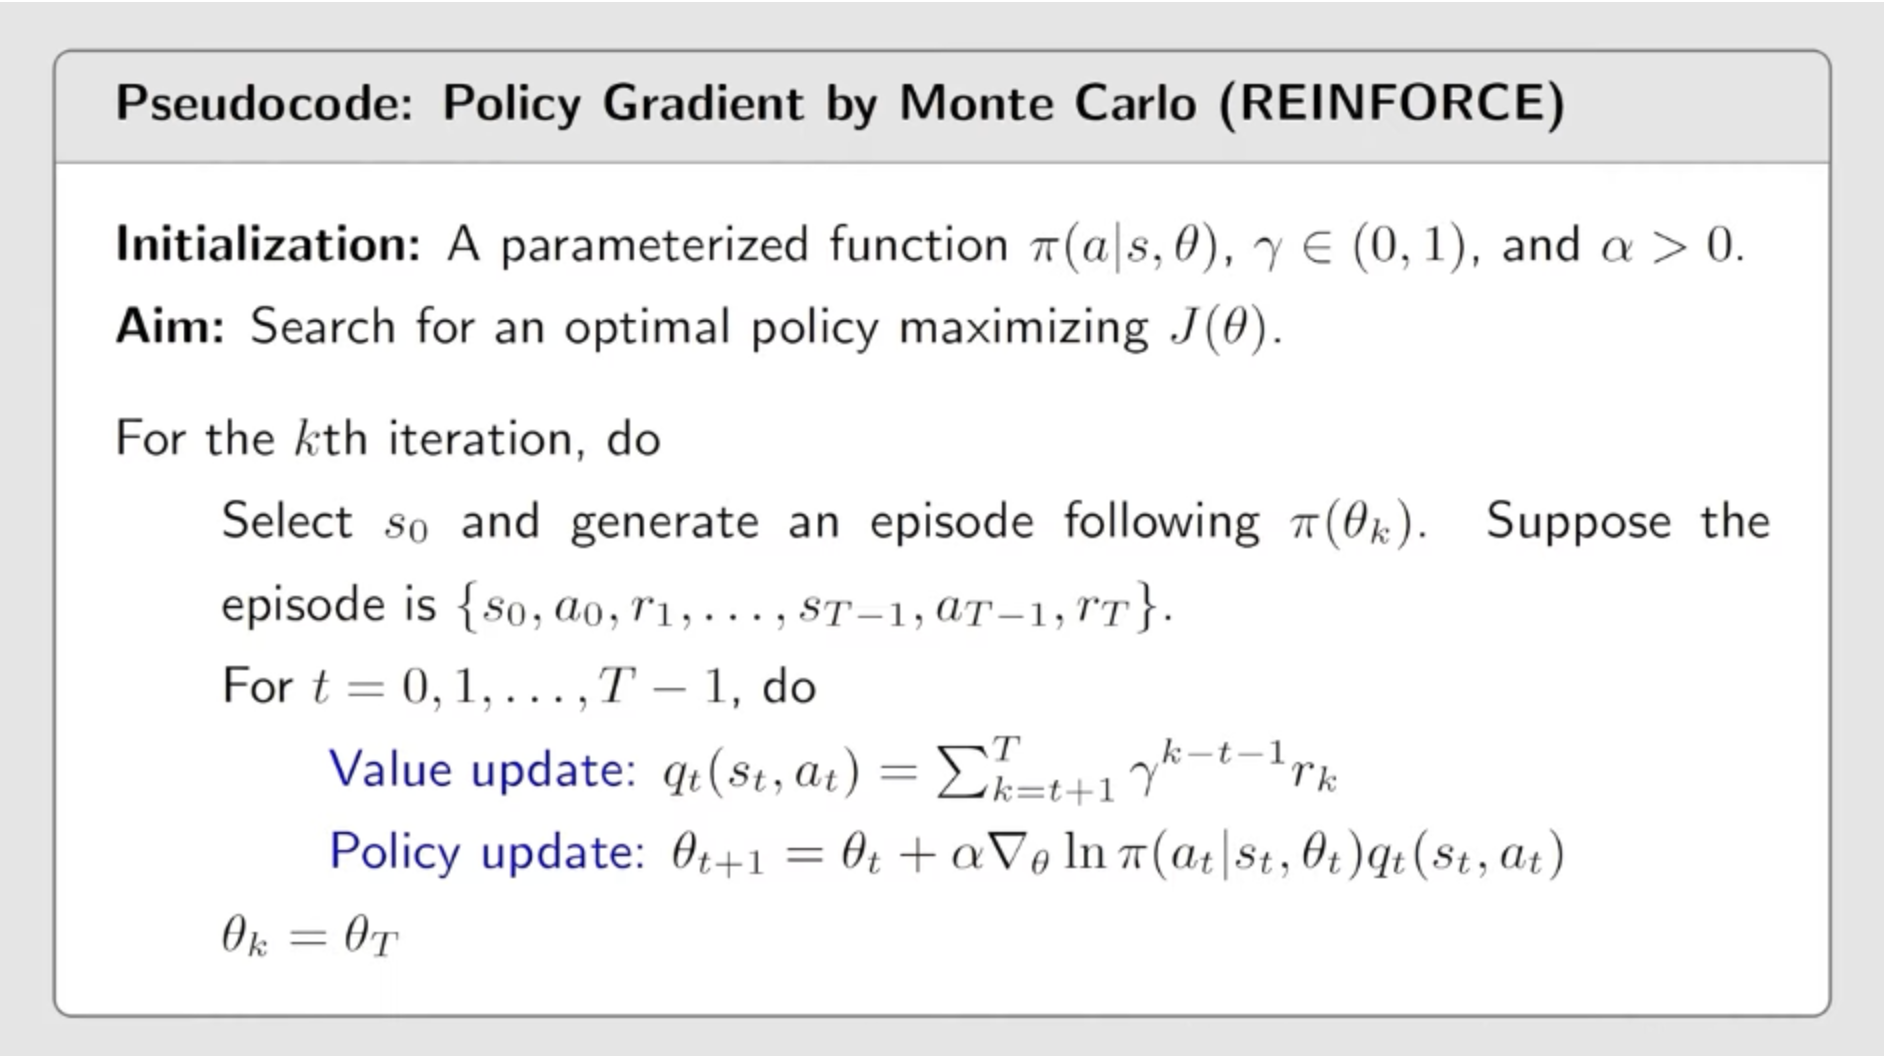

1. Forward PassThe probability of selecting action $a_k$ (the $k$-th action) in state $s$ is defined by the softmax of the linear preferences for each action.
   $$\pi(a_k|s, \theta) = \frac{e^{x^T \theta_k}}{\sum_{j=1}^{n} e^{x^T \theta_j}}$$
where:
- $x$ is the feature vector of dimension
- $d \times 1$.$\theta$ is the weight matrix of dimension $d \times n$
- $\theta_k$ is the $k$-th column of the matrix $\theta$, representing the weights for action $k$

2. Log DerivativeTaking the natural logarithm of both sides:
    $$\ln \pi(a_k|s, \theta) = \ln\left(\frac{e^{x^T \theta_k}}{\sum_{j=1}^{n} e^{x^T \theta_j}}\right)$$

 - Using the identity $\ln(\frac{A}{B}) = \ln A - \ln B$:
     $$\ln \pi(a_k|s, \theta) = x^T \theta_k - \ln\left(\sum_{j=1}^{n} e^{x^T \theta_j}\right)$$

Derivative with respect to $\theta$
To maintain dimensional consistency, we differentiate with respect to a specific column $\theta_w$ of the weight matrix
$$\nabla_{\theta_w} \ln \pi(a_k|s, \theta) = \nabla_{\theta_w} (x^T \theta_k) - \nabla_{\theta_w} \ln\left(\sum_{j=1}^{n} e^{x^T \theta_j}\right)$$

First Part:
If $w = k$ (the action we took), the derivative is $x$ 
If $w \neq k$, the derivative is $0$

$$\nabla_{\theta_w} (x^T \theta_k) = \mathbb{I}_{w=k} x$$

Second Part:Using the chain rule $\nabla \ln(u) = \frac{1}{u} \nabla u$:
   $$\nabla_{\theta_w} \ln\left(\sum_{j=1}^{n} e^{x^T \theta_j}\right) = \frac{1}{\sum_{j=1}^{n} e^{x^T \theta_j}} \left( \nabla_{\theta_w} \sum_{j=1}^{n} e^{x^T \theta_j} \right)$$
   $$= \frac{1}{\sum_{j=1}^{n} e^{x^T \theta_j}} (e^{x^T \theta_w} x) = \pi(a_w|s, \theta) x$$
   
3. Final Score Function (Gradient Matrix)Combining the parts, the gradient with respect to the $w$-th column of the weight matrix is:
   $$\nabla_{\theta_w} \ln \pi(a_k|s, \theta) = (\mathbb{I}_{w=k} - \pi(a_w|s, \theta)) x$$
In matrix form (to update the entire $d \times n$ matrix $\theta$ at once), this is expressed as an outer product:
   $$\nabla_\theta \ln \pi(a_k|s, \theta) = x (\mathbf{e}_k - \boldsymbol{\pi})^T$$
where:
   - $x$ is $d \times 1$
   - $\mathbf{e}_k$ is a one-hot vector ($n \times 1$) for the action taken
   - $\boldsymbol{\pi}$ is the probability vector ($n \times 1$)
   - The result is a $d \times n$ matrix, matching $\theta$

In [1]:
## Implementation

In [2]:
import random
import math
from collections import deque

from frozen_lake_environment import (generate_grid_randomly,
                                     FrozenLakeEnvironment,
                                     State)
import numpy as np
from matplotlib import pyplot
from visual_utils import (render_policy_and_value, 
                          animate_policy_value_video,
                          plot_trajectory_history)

In [3]:
def random_choice(values, probs):
    r = random.random()
    cumulative = 0.0
    for i in range(len(probs)):
        p = probs[i]
        cumulative += p
        if r <= cumulative:
            return values[i], probs[i]
    return values[-1], probs[-1]  # fallback for floating point edge case

def softmax(z):
    # Subtracting the max value prevents overflow in the exp function
    shift_z = z - np.max(z)
    exp_z = np.exp(shift_z)
    return exp_z / np.sum(exp_z)
    

def soft_policy(theta, state_feat_vec, env):    
    state_feat_vec = np.array(state_feat_vec).reshape(-1, 1)  # state_dim X 1

    # --- linear combination --------
    action_logits = (state_feat_vec.T @ theta).squeeze(0)
    action_probs = softmax(action_logits)
    # print(action_probs)
    # ------------------------------
    action, action_prob = random_choice(env.all_action_idx,
                                        action_probs)
    return action, action_probs

def get_policy_table(theta, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    policy = np.zeros(env.n_states, dtype=np.int8)

    for state in states:
        state_feat_vec = state.get_state_feature_vec(env.n_states)
        state_feat_vec = np.array(state_feat_vec).reshape(-1, 1)  # state_dim X 1
        # X^T * theta
        action_probs = (state_feat_vec.T @ theta).squeeze(0) # n_action_dim
        action, action_prob = random_choice(env.all_action_idx, action_probs)
        policy[state.idx] = np.argmax(action_probs).item()
    return policy

In [4]:
n_states = 9
n_actions = 4

lake_grid = [["G", "F", "F"],
             ["F", "F", "F"],
             ["F", "H", "S"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

theta = np.random.uniform(size=(n_states, n_actions))
theta


array([[0.17995707, 0.1121973 , 0.06849207, 0.86824055],
       [0.0405903 , 0.20425594, 0.21826074, 0.99580581],
       [0.88220532, 0.74881637, 0.47721762, 0.43364758],
       [0.26086998, 0.09548043, 0.85022042, 0.14624147],
       [0.19209613, 0.63411569, 0.68135992, 0.04285946],
       [0.43205925, 0.97923259, 0.00725615, 0.57227921],
       [0.3331321 , 0.8507929 , 0.55622413, 0.37631178],
       [0.13358445, 0.4008198 , 0.93885459, 0.87025757],
       [0.64642852, 0.20405406, 0.69515733, 0.97656074]])

In [5]:
state_feat_vec = np.array([0, 1, 0, 0, 0, 0, 0, 0, 0]).reshape(-1, 1)
state_feat_vec.shape

(9, 1)

In [6]:
(state_feat_vec.T @ theta).squeeze(0)

array([0.0405903 , 0.20425594, 0.21826074, 0.99580581])

In [7]:
soft_policy(theta, [0, 1, 0, 0, 0, 0, 0, 0, 0], frozen_lake)

(3, array([0.1674626 , 0.19724087, 0.20002262, 0.43527392]))

In [8]:
get_policy_table(theta, frozen_lake)

array([3, 3, 0, 2, 2, 1, 1, 2, 3], dtype=int8)

In [9]:
def run_episode(env, theta, state, max_step=10000, episode_idx=0):
    """
    verbose : 
      - 0 : None 
      - 1 : CLI
      - 2 : GUI  
    """
    
    trajectory = []

    # --- initial action -----
    state_feature_vec = state.get_state_feature_vec(env.n_states) 
    action, action_probs = soft_policy(theta,
                                      state_feature_vec,
                                      env)
    
    for step in range(max_step):
        result = env.step(state, action)
        reward = result["reward"]
        trajectory.append((state, action, action_probs, reward))
        
        next_state = result["new_state"]
        is_terminated = result["is_terminated"]

        if is_terminated:
            break
        
        state_feature_vec = next_state.get_state_feature_vec(env.n_states)
        next_action, next_action_probs = soft_policy(theta,
                                                    state_feature_vec,
                                                    env)
        state = next_state
        action = next_action
        action_probs = next_action_probs
    return trajectory

$$\nabla_\theta \ln \pi = x(s) \cdot (\mathbf{e}_k - \boldsymbol{\pi})^T$$

In [10]:

def compute_score_function_gradient(state_feat_vec, action_probs, action_idx):
    # 1. Ensure state_feat_vec is a column vector (d x 1)
    x = np.array(state_feat_vec).reshape(-1, 1) 
    
    # 2. Create a one-hot vector for the action taken (n x 1)
    e_k = np.zeros_like(action_probs).reshape(-1, 1)
    e_k[action_idx] = 1.0
    
    # 3. Reshape action_probs to a column vector (n x 1)
    pi = np.array(action_probs).reshape(-1, 1)
    
    # 4. Compute the error (n x 1)
    # This tells us how much to "push" each action's weights
    error = e_k - pi
    
    # 5. Compute the Outer Product (d x 1) @ (1 x n) -> (d x n)
    # This result has the same shape as your weight matrix 'theta'
    gradient = x @ error.T
    
    return gradient

In [11]:
def run_reinforce_learning(env, n_episodes=500, gamma=0.99, alpha=0.001):
    policy_histories = []
    Q_histories = []
    trajectory_histories = []

    # ---- learning parameter -----
    theta =  np.random.uniform(size=(env.n_states, env.n_actions))
    # -----------------------------
    rewards = []
    for episode_idx in range(n_episodes):
        # --- initial state -----
        state = env.find('S')
        # -----------------------------------        
        episode_reward = 0
        
        trajectory = run_episode(env,
                                 theta,
                                 state)
        
        Q = np.zeros((env.n_states, env.n_actions), dtype=np.float32)

        G = 0
        

        for transition_step in reversed(trajectory):
            s, a, a_probs, r = transition_step
            
            # ----- value update --------
            G = r + gamma * G
            Q[s.idx][a] = G
 
            # ----- policy update ----
            state_feat_vec = s.get_state_feature_vec(env.n_states)
            theta = theta + alpha * compute_score_function_gradient(state_feat_vec, a_probs, a) * G
            episode_reward += r
        
        rewards.append(episode_reward)
        trajectory_histories.append([traj[0].coord for traj in trajectory])
        
        if episode_idx % 5000 == 0:
            avg = np.mean(rewards[-100:])
            print(f"Episode {episode_idx} | Avg Reward: {avg:.3f}")
            policy = get_policy_table(theta, env)
            print("policy: ", policy)
            
            policy_histories.append(policy)
            Q_histories.append(Q)
            
    return policy_histories, Q_histories, trajectory_histories

In [12]:
lake_grid = [["G", "F", "F", "F"],
             ["F", "H", "H", "F"],
             ["F", "F", "F", "F"],
             ["H", "F", "S", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [13]:
policy_histories, q_histories, trajectory_histories = run_reinforce_learning(frozen_lake, n_episodes=10000)

Episode 0 | Avg Reward: 0.000
policy:  [3 3 1 1 2 0 0 1 1 3 1 2 0 3 0 3]
Episode 5000 | Avg Reward: 0.500
policy:  [3 3 0 1 3 0 0 1 3 0 0 1 0 3 0 3]


In [14]:
policy = policy_histories[-1]
q_table = q_histories[-1]

In [15]:
# trajectory_histories

In [16]:
# q_histories[-1]

# Render policy

In [17]:
import pandas as pd
from IPython.display import display

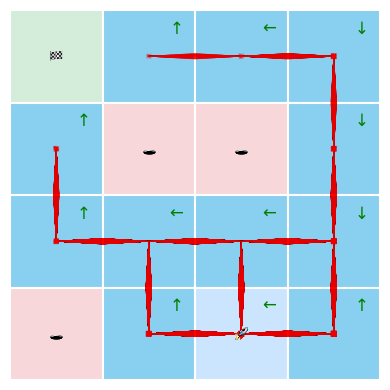

In [18]:
plot_trajectory_history(frozen_lake, trajectory_histories, policy)